In [37]:
import numpy as np
import matplotlib.pyplot as plt
from function_library_OOP import DetectorSetup

In [38]:
directory = "MS_in_air_Plots"

rescaling_factor = 10**6   # 10^6 µm = 1 m

plt.rcParams["figure.figsize"] = (5,5)
xlabel = "$p_{T}$ [GeV/c]"
ylabel = "$\sigma_{r \phi}$ [$\mu m$]"

### Global variables and detector initialization

In [39]:
spatial_resolution_ITS2 = 5 * 10**-6
average_layer_radii_ITS2 = np.array([23, 31, 39, 196, 245, 344, 393]) * 10**-3               # average radius of ITS2 layers in meters
layerthickness_ITS2 = [0.0035, 0.0035, 0.0035, 0.0110, 0.0110, 0.0110, 0.0110]               # thickness of the detector planes in units of radiation length 0.35% X0 inner and 1.1% X0 outer
detector_resolutions_rphi_ITS2 = [spatial_resolution_ITS2 for i in range(7)]                 # spatial resolution of the ITS2 layers in rphi in meters
detector_resolutions_z_ITS2 = [spatial_resolution_ITS2 for i in range(7)]                    # spatial resolution of the ITS2  layers in z    in meters
radiation_length_air_ITS2 = 303.9                                                            # radiation length of air in meters
magnetic_field_strength_ITS2 = 0.5                                                           # strength of magnetic field in Alice in Tesla

ITS2 = DetectorSetup(average_layer_radii_ITS2, layerthickness_ITS2, detector_resolutions_rphi_ITS2, detector_resolutions_z_ITS2, radiation_length_air_ITS2, magnetic_field_strength_ITS2)

Detector Setup initialized


#### Protons

In [40]:
proton_mass = 1
proton_momenta = np.arange(0.2, 10, 0.1)

N = 4
extrapolation_radii = np.array([0.01, 0.1, 1]) 
theta = 90

proton_rphi_wMS = np.array([[ITS2.transverse_track_position_uncertainty(p, proton_mass, N, r, theta) for p in proton_momenta] for r in extrapolation_radii])
proton_z_wMS = np.array([[ITS2.longitudinal_track_position_uncertainty(p, proton_mass, N, r, theta) for p in proton_momenta] for r in extrapolation_radii])
proton_pT_wMS = np.array([ITS2.transverse_momentum_reso(p, proton_mass, N, theta) for p in proton_momenta])

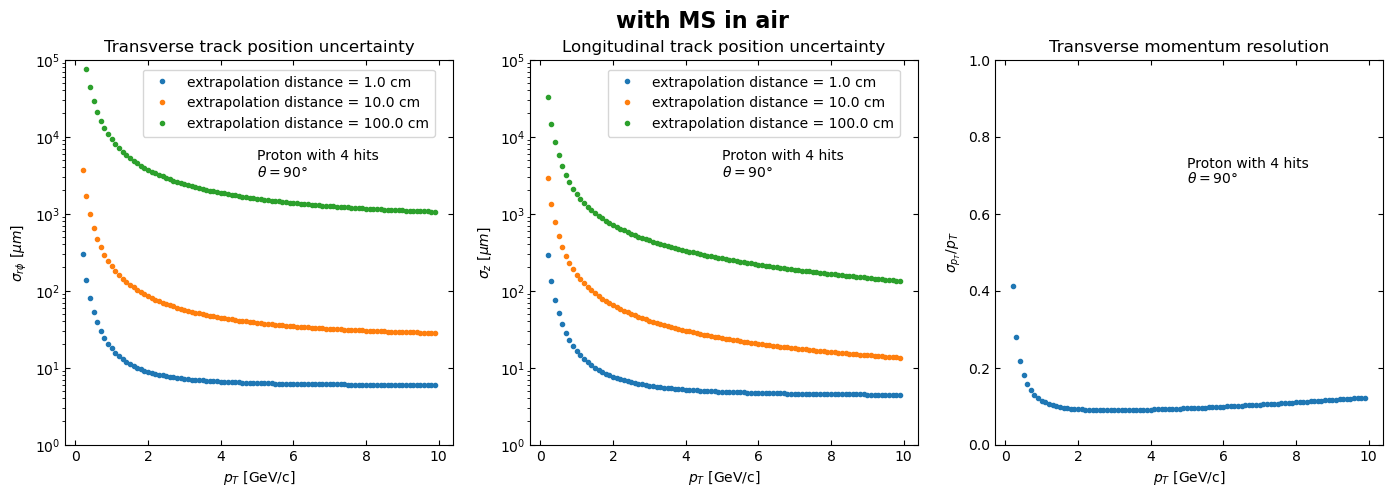

In [41]:
fig, axs = plt.subplots(1,3, figsize=(17,5))

for i, r in enumerate(extrapolation_radii):
    axs[0].plot(proton_momenta, proton_rphi_wMS[i]*rescaling_factor, ".", label=f"extrapolation distance = {r*100} cm")
axs[0].set_title("Transverse track position uncertainty")
axs[0].set(xlabel = xlabel, ylabel = "$\sigma_{r \phi}$ [$\mu m$]", ylim=(1, 10**5), yscale="log")
axs[0].tick_params(top=True, right=True, direction="in")
axs[0].text(5, 5000, "Proton with 4 hits")
axs[0].text(5, 3000, fr"$\theta = {theta}$°")
axs[0].legend(loc=(0.2, 0.8))

for i, r in enumerate(extrapolation_radii):
    axs[1].plot(proton_momenta, proton_z_wMS[i]*rescaling_factor, ".", label=f"extrapolation distance = {r*100} cm")
axs[1].set_title("Longitudinal track position uncertainty")
axs[1].set(xlabel = xlabel, ylabel = "$\sigma_{z}$ [$\mu m$]", ylim=(1, 10**5), yscale="log")
axs[1].tick_params(top=True, right=True, direction="in")
axs[1].text(5, 5000, "Proton with 4 hits")
axs[1].text(5, 3000, fr"$\theta = {theta}$°")
axs[1].legend(loc=(0.2, 0.8))

axs[2].set_title("Transverse momentum resolution")
axs[2].plot(proton_momenta, proton_pT_wMS, ".")
axs[2].set(xlabel = xlabel, ylabel = "$\sigma_{p_{T}} / p_T$", ylim=(0, 1))
axs[2].tick_params(top=True, right=True, direction="in")
axs[2].text(5, 0.72, "Proton with 4 hits")
axs[2].text(5, 0.68, fr"$\theta = {theta}$°")

fig.suptitle("with MS in air", fontsize=16, fontweight="bold")
fig.savefig(f"{directory}/Proton_wMS.png", dpi = 200)

In [42]:
ITS2 = DetectorSetup(average_layer_radii_ITS2, layerthickness_ITS2, detector_resolutions_rphi_ITS2, detector_resolutions_z_ITS2, radiation_length_air_ITS2, magnetic_field_strength_ITS2)
ITS2.MS_in_air = False

Detector Setup initialized


In [43]:
proton_rphi_woMS = np.array([[ITS2.transverse_track_position_uncertainty(p, proton_mass, N, r, theta) for p in proton_momenta] for r in extrapolation_radii])
proton_z_woMS = np.array([[ITS2.longitudinal_track_position_uncertainty(p, proton_mass, N, r, theta) for p in proton_momenta] for r in extrapolation_radii])
proton_pT_woMS = np.array([ITS2.transverse_momentum_reso(p, proton_mass, N, theta) for p in proton_momenta])
proton_rphi_woMS.shape

(3, 98)

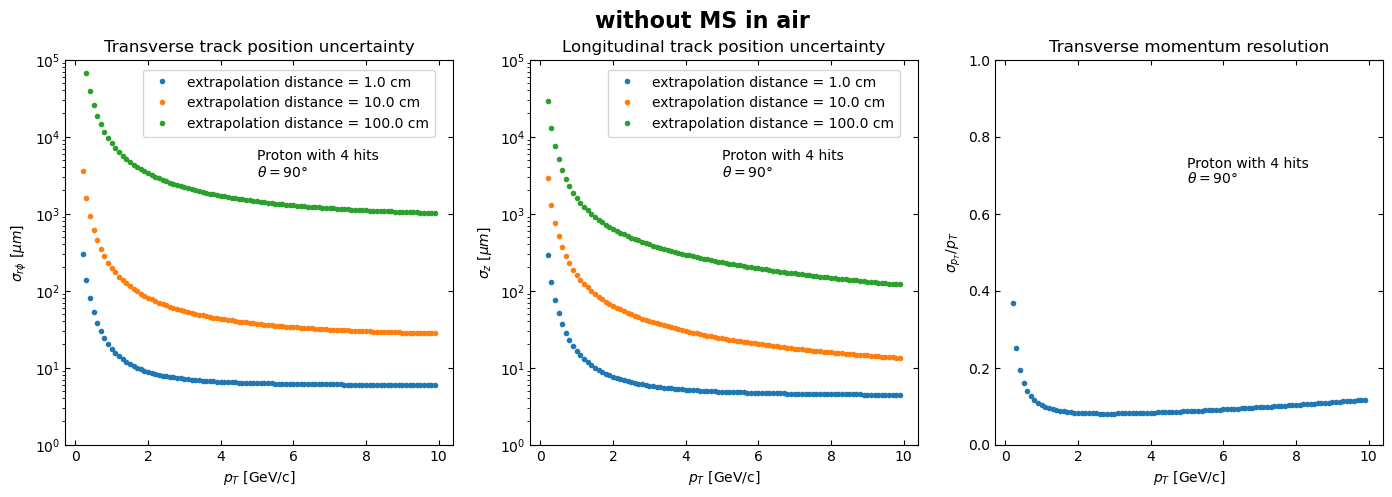

In [44]:
fig, axs = plt.subplots(1,3, figsize=(17,5))

for i, r in enumerate(extrapolation_radii):
    axs[0].plot(proton_momenta, proton_rphi_woMS[i]*rescaling_factor, ".", label=f"extrapolation distance = {r*100} cm")
axs[0].set_title("Transverse track position uncertainty")
axs[0].set(xlabel = xlabel, ylabel = "$\sigma_{r \phi}$ [$\mu m$]", ylim=(1, 10**5), yscale="log")
axs[0].tick_params(top=True, right=True, direction="in")
axs[0].text(5, 5000, "Proton with 4 hits")
axs[0].text(5, 3000, fr"$\theta = {theta}$°")
axs[0].legend(loc=(0.2, 0.8))

for i, r in enumerate(extrapolation_radii):
    axs[1].plot(proton_momenta, proton_z_woMS[i]*rescaling_factor, ".", label=f"extrapolation distance = {r*100} cm")
axs[1].set_title("Longitudinal track position uncertainty")
axs[1].set(xlabel = xlabel, ylabel = "$\sigma_{z}$ [$\mu m$]", ylim=(1, 10**5), yscale="log")
axs[1].tick_params(top=True, right=True, direction="in")
axs[1].text(5, 5000, "Proton with 4 hits")
axs[1].text(5, 3000, fr"$\theta = {theta}$°")
axs[1].legend(loc=(0.2, 0.8))

axs[2].set_title("Transverse momentum resolution")
axs[2].plot(proton_momenta, proton_pT_woMS, ".")
axs[2].set(xlabel = xlabel, ylabel = "$\sigma_{p_{T}} / p_T$", ylim=(0, 1))
axs[2].tick_params(top=True, right=True, direction="in")
axs[2].text(5, 0.72, "Proton with 4 hits")
axs[2].text(5, 0.68, fr"$\theta = {theta}$°")

fig.suptitle("without MS in air", fontsize=16, fontweight="bold")
fig.savefig(f"{directory}/Proton_woMS.png", dpi = 200)

#### Protons visualize the differences with residuals or scaled residuals

In [45]:
proton_rphi_diff = proton_rphi_wMS - proton_rphi_woMS
proton_z_diff = proton_z_wMS - proton_z_woMS
proton_pT_diff = proton_pT_wMS - proton_pT_woMS

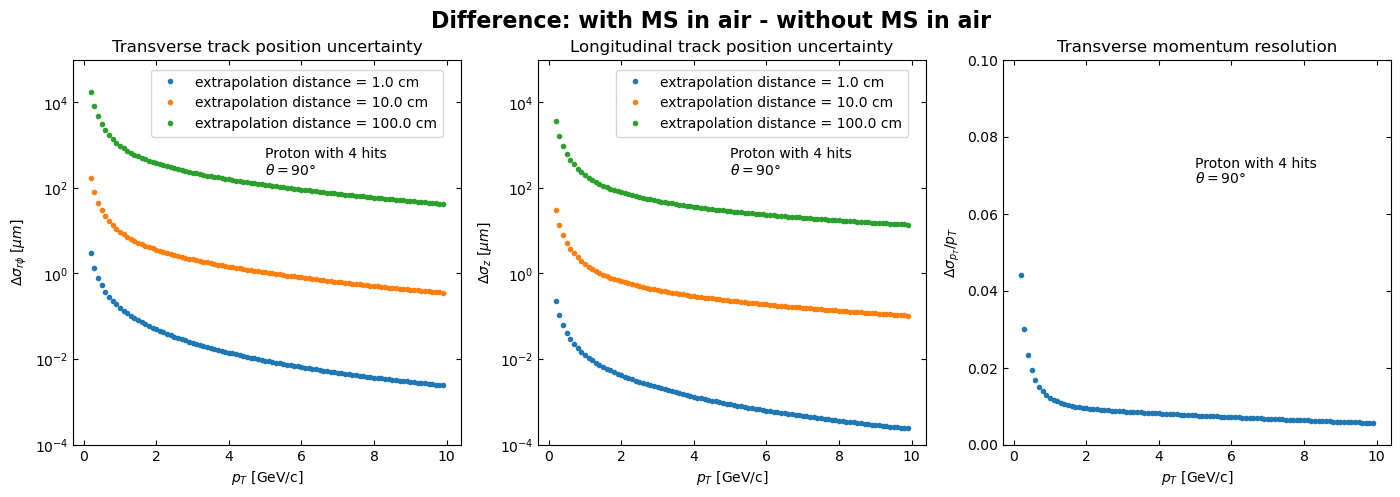

In [46]:
fig, axs = plt.subplots(1,3, figsize=(17,5))

for i, r in enumerate(extrapolation_radii):
    axs[0].plot(proton_momenta, proton_rphi_diff[i]*rescaling_factor, ".", label=f"extrapolation distance = {r*100} cm")
axs[0].set_title("Transverse track position uncertainty")
axs[0].set(xlabel = xlabel, ylabel = "$\Delta \sigma_{r \phi}$ [$\mu m$]", ylim=(10**-4, 10**5), yscale="log")
axs[0].tick_params(top=True, right=True, direction="in")
axs[0].text(5, 500, "Proton with 4 hits")
axs[0].text(5, 200, fr"$\theta = {theta}$°")
axs[0].legend(loc=(0.2, 0.8))

for i, r in enumerate(extrapolation_radii):
    axs[1].plot(proton_momenta, proton_z_diff[i]*rescaling_factor, ".", label=f"extrapolation distance = {r*100} cm")
axs[1].set_title("Longitudinal track position uncertainty")
axs[1].set(xlabel = xlabel, ylabel = "$\Delta \sigma_{z}$ [$\mu m$]", ylim=(10**-4, 10**5), yscale="log")
axs[1].tick_params(top=True, right=True, direction="in")
axs[1].text(5, 500, "Proton with 4 hits")
axs[1].text(5, 200, fr"$\theta = {theta}$°")
axs[1].legend(loc=(0.2, 0.8))

axs[2].set_title("Transverse momentum resolution")
axs[2].plot(proton_momenta, proton_pT_diff, ".")
axs[2].set(xlabel = xlabel, ylabel = "$\Delta \sigma_{p_{T}} / p_T$", ylim=(0, 0.1))
axs[2].tick_params(top=True, right=True, direction="in")
axs[2].text(5, 0.072, "Proton with 4 hits")
axs[2].text(5, 0.068, fr"$\theta = {theta}$°")

fig.suptitle("Difference: with MS in air - without MS in air", fontsize=16, fontweight="bold")
fig.savefig(f"{directory}/Proton_diff.png", dpi = 200)

In [47]:
proton_rphi_diff_scaled = (proton_rphi_wMS - proton_rphi_woMS) / proton_rphi_woMS
proton_z_diff_scaled = (proton_z_wMS - proton_z_woMS) / proton_z_woMS
proton_pT_diff_scaled = (proton_pT_wMS - proton_pT_woMS) / proton_pT_woMS

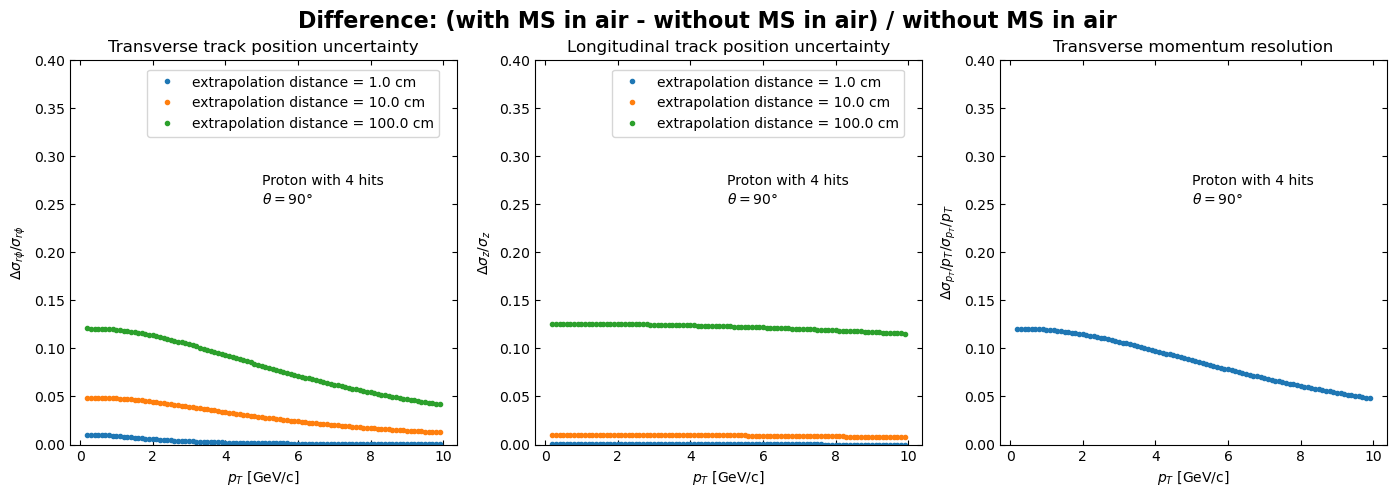

In [48]:
fig, axs = plt.subplots(1,3, figsize=(17,5))

for i, r in enumerate(extrapolation_radii):
    axs[0].plot(proton_momenta, proton_rphi_diff_scaled[i], ".", label=f"extrapolation distance = {r*100} cm")
axs[0].set_title("Transverse track position uncertainty")
axs[0].set(xlabel = xlabel, ylabel = "$\Delta \sigma_{r \phi} / \sigma_{r \phi}$ ", ylim=(0, 0.4))
axs[0].tick_params(top=True, right=True, direction="in")
axs[0].text(5, 0.27, "Proton with 4 hits")
axs[0].text(5, 0.25, fr"$\theta = {theta}$°")
axs[0].legend(loc=(0.2, 0.8))

for i, r in enumerate(extrapolation_radii):
    axs[1].plot(proton_momenta, proton_z_diff_scaled[i], ".", label=f"extrapolation distance = {r*100} cm")
axs[1].set_title("Longitudinal track position uncertainty")
axs[1].set(xlabel = xlabel, ylabel = "$\Delta \sigma_{z} / \sigma_{z}$ ", ylim=(0, 0.4))
axs[1].tick_params(top=True, right=True, direction="in")
axs[1].text(5, 0.27, "Proton with 4 hits")
axs[1].text(5, 0.25, fr"$\theta = {theta}$°")
axs[1].legend(loc=(0.2, 0.8))

axs[2].set_title("Transverse momentum resolution")
axs[2].plot(proton_momenta, proton_pT_diff_scaled, ".")
axs[2].set(xlabel = xlabel, ylabel = "$\Delta \sigma_{p_{T}} / p_T / \sigma_{p_{T}} / p_T$", ylim=(0, 0.4))
axs[2].tick_params(top=True, right=True, direction="in")
axs[2].text(5, 0.27, "Proton with 4 hits")
axs[2].text(5, 0.25, fr"$\theta = {theta}$°")

fig.suptitle("Difference: (with MS in air - without MS in air) / without MS in air", fontsize=16, fontweight="bold")
fig.savefig(f"{directory}/Proton_diff_scaled.png", dpi = 200)